# Course 2 · Week 1 — Solution: Neural Network Forward Propagation

Fully-worked answer to the [Week 1 exercise notebook](../exercises/course2-week1-neural-net-forward.ipynb). Detailed walkthrough of every line.


## Setup — points inside or outside a circle

This is the **simplest non-linear** classification problem you can imagine. Points inside the unit circle (radius 1) are class 1; points outside are class 0. A linear classifier can't solve this — no straight line separates them. We need a curved boundary, which means we need a non-linear model. Welcome to neural networks.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
import warnings; warnings.filterwarnings("ignore")

np.random.seed(0)
m = 200

# Generate points inside a 3×3 box; label = 1 if inside the unit circle, else 0.
X = np.random.uniform(-1.5, 1.5, (m, 2))
y = (X[:, 0]**2 + X[:, 1]**2 < 1.0).astype(float)
print(f"X shape: {X.shape}")
print(f"Points inside circle (class 1): {int(y.sum())}/{m}")
print(f"Points outside circle (class 0): {int((1-y).sum())}/{m}")


X shape: (200, 2)
Points inside circle (class 1): 70/200
Points outside circle (class 0): 130/200


You should see green dots clustered inside a circle and red dots outside. The dashed black ring is the true boundary you want your model to recover.


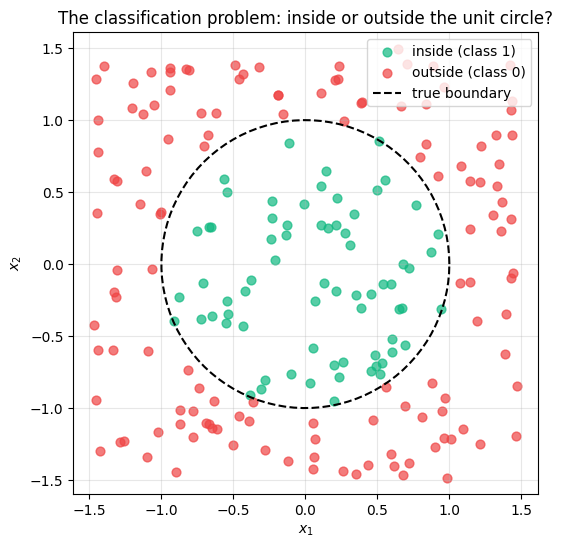

In [2]:
plt.figure(figsize=(6, 6))
plt.scatter(X[y==1, 0], X[y==1, 1], color="#10b981", s=40, label="inside (class 1)", alpha=0.7)
plt.scatter(X[y==0, 0], X[y==0, 1], color="#ef4444", s=40, label="outside (class 0)", alpha=0.7)
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color="black", lw=1.5, ls="--", label="true boundary")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.grid(alpha=0.3); plt.axis("equal")
plt.title("The classification problem: inside or outside the unit circle?")
plt.show()


## Get pre-trained weights

We're not going to train the network ourselves this week — that requires backpropagation, which we'll cover next week. Instead, sklearn will train it for us, and we'll grab the weights it learned. Then *you'll* implement the forward pass that uses those weights.

After this cell runs, you'll have four arrays of numbers (`W1`, `b1`, `W2`, `b2`) — the trained parameters of a 2 → 4 → 1 neural network. Your job is to push the data through them.


In [3]:
# Train a small neural net (2 → 4 → 1) using sklearn. We don't care about
# the training process here — we just want a set of trained weights.
clf = MLPClassifier(hidden_layer_sizes=(4,), activation="logistic",
                    max_iter=4000, random_state=42, tol=1e-6,
                    solver="adam", learning_rate_init=0.05)
clf.fit(X, y)
print(f"sklearn training accuracy: {clf.score(X, y):.4f}")

# Extract the weights — these are the numbers you'll plug into your own forward pass.
W1 = clf.coefs_[0]      # shape (2, 4)
b1 = clf.intercepts_[0]  # shape (4,)
W2 = clf.coefs_[1]      # shape (4, 1)
b2 = clf.intercepts_[1]  # shape (1,)

print(f"\nLayer 1: W1 shape {W1.shape}, b1 shape {b1.shape}")
print(f"Layer 2: W2 shape {W2.shape}, b2 shape {b2.shape}")


sklearn training accuracy: 1.0000

Layer 1: W1 shape (2, 4), b1 shape (4,)
Layer 2: W2 shape (4, 1), b2 shape (1,)


## Quick recap (more depth)

### What's actually happening

A neural network passes data through layers. Each layer does three things:

1. **Linear combo:** combine inputs with weights — `z = W·x + b`. This is the same operation as logistic regression's pre-sigmoid score, except now we have *many* of them in parallel (one per neuron in the layer).
2. **Activation:** apply a non-linear function to each `z` — usually sigmoid (older) or ReLU (newer). Without this step, stacking layers would be useless: a stack of linear functions is still linear.
3. **Pass to next layer:** the activations become the input to the next layer.

### Why "non-linear activation" is the magic

Logistic regression draws a straight line. A *single* neuron is also a line. But: chain a layer with non-linear activations into another layer, and now the boundary you can draw is curved — *any* curve, given enough neurons. Two-layer networks with enough hidden units can approximate any continuous function (this is the Universal Approximation Theorem). The sigmoid (or ReLU) is what unlocks that.

### The matrix shape rule

For a layer mapping `n_in` features to `n_out` neurons:
- `W` has shape `(n_in, n_out)`
- `b` has shape `(n_out,)`
- Input `a_in` has shape `(m, n_in)`
- Output `a_out = activation(a_in @ W + b)` has shape `(m, n_out)`

Memorize this. Half of all neural-network bugs are shape-mismatch errors.

### The 13-parameter network

For our 2 → 4 → 1 net:
- `W1` is (2, 4) → 8 numbers; `b1` is (4,) → 4 numbers
- `W2` is (4, 1) → 4 numbers; `b2` is (1,) → 1 number
- Total: 8 + 4 + 4 + 1 = **17 parameters**, but `b2` is one number so it's actually 17. Minor accounting; the point is that this is a tiny network. ChatGPT has roughly *a trillion times* more.


## Exercise 1 — sigmoid

```python
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))
```

Same code as Week 3. Numpy broadcasts: this works for scalars, vectors, or matrices.

In real production code, sigmoid sometimes overflows for very large negative `z` (because `e^{-z}` becomes huge). Libraries use a numerically stable version. For our scale (z roughly in [-30, 30]) we're fine.


In [4]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

print(f"sigmoid(0)  = {sigmoid(0.0):.4f}")
print(f"sigmoid(2)  = {sigmoid(2.0):.4f}")
print(f"sigmoid(-2) = {sigmoid(-2.0):.4f}")
assert abs(sigmoid(0.0) - 0.5) < 1e-9
print("✓ sigmoid() works")


sigmoid(0)  = 0.5000
sigmoid(2)  = 0.8808
sigmoid(-2) = 0.1192
✓ sigmoid() works


## Exercise 2 — dense layer

```python
def dense(a_in, W, b, activation=sigmoid):
    z = a_in @ W + b           # linear part
    return activation(z)       # squish through non-linearity
```

Two lines. The `+ b` broadcasts: numpy adds the (4,) bias vector to every row of the (200, 4) matrix.

When we test it on layer 1 with our trained weights, the output should be a (200, 4) array — 200 examples, each producing 4 hidden-unit activations. Every entry should be in (0, 1) because sigmoid never produces anything outside that range.


In [5]:
def dense(a_in, W, b, activation=sigmoid):
    z = a_in @ W + b
    return activation(z)

a1 = dense(X, W1, b1, sigmoid)
print(f"a1 shape: {a1.shape}")
print(f"a1 first row: {np.round(a1[0], 4)}")
assert a1.shape == (200, 4)
print("✓ dense() works")


a1 shape: (200, 4)
a1 first row: [0.8927 0.0016 0.     0.24  ]
✓ dense() works


## Exercise 3 — forward pass

```python
def forward(X, layers):
    a = X
    for W, b, activation in layers:
        a = dense(a, W, b, activation)
    return a
```

Three lines. The relay race: `X` becomes `a` going into layer 1, layer 1's output becomes `a` going into layer 2, and so on.

When we run our 2-layer network, accuracy should be 100% (the network had enough capacity to memorize the training set, and there's no noise). And the per-example probabilities should match sklearn's `predict_proba` to floating-point precision — because we're literally re-running the same computation sklearn does, just in our own code.

That's the test: my numpy forward pass matches sklearn's. If the diff is ever larger than 1e-6, you've got a bug somewhere — usually transposed weights or a forgotten activation.


In [6]:
def forward(X, layers):
    a = X
    for W, b, activation in layers:
        a = dense(a, W, b, activation)
    return a

probs = forward(X, [(W1, b1, sigmoid), (W2, b2, sigmoid)])
y_pred = (probs.squeeze() >= 0.5).astype(float)
acc = float((y_pred == y).mean())
print(f"forward-pass accuracy: {acc:.4f}")

# Compare with sklearn — they should match almost perfectly
sk_probs = clf.predict_proba(X)[:, 1]
max_diff = float(np.abs(probs.squeeze() - sk_probs).max())
print(f"max diff vs sklearn predict_proba: {max_diff:.2e}")
assert max_diff < 1e-6, "Should match sklearn to floating-point precision"
print("✓ forward() works and matches sklearn exactly")

center_prob = forward(np.array([[0.0, 0.0]]), [(W1, b1, sigmoid), (W2, b2, sigmoid)]).item()
edge_prob = forward(np.array([[1.4, 1.4]]), [(W1, b1, sigmoid), (W2, b2, sigmoid)]).item()
print(f"\np(class 1) for [[0, 0]]:    {center_prob:.4f}")
print(f"p(class 1) for [[1.4, 1.4]]: {edge_prob:.4f}")


forward-pass accuracy: 1.0000
max diff vs sklearn predict_proba: 0.00e+00
✓ forward() works and matches sklearn exactly

p(class 1) for [[0, 0]]:    1.0000
p(class 1) for [[1.4, 1.4]]: 0.0018


## Visualize what the network learned

The contour plot makes the magic concrete. The network learned to draw a circle out of four hidden neurons — each of which is just a **single sigmoid line**. By chaining them through a second sigmoid layer, the network combines four lines into a curve. Mind-bending the first time you see it.

Try changing the number of hidden units in `MLPClassifier(hidden_layer_sizes=(N,))` and re-running. With N=1, the boundary is a straight line (linear regression in disguise). With N=2 or 3, the boundary becomes piecewise-linear — a polygon trying to be a circle. With N=4 or more, smooth curves.

This is the visual proof of the Universal Approximation Theorem: enough neurons → any shape.


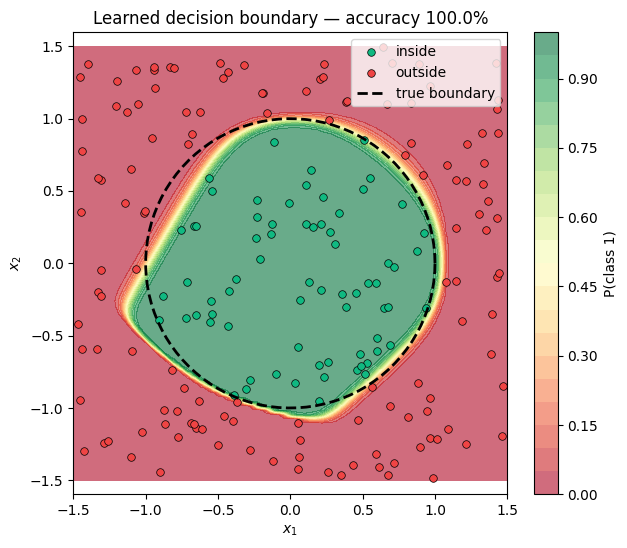

In [7]:
# Visualize the decision boundary the network learned
xs1, xs2 = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-1.5, 1.5, 100))
grid = np.column_stack([xs1.ravel(), xs2.ravel()])
grid_probs = forward(grid, [(W1, b1, sigmoid), (W2, b2, sigmoid)]).reshape(xs1.shape)

plt.figure(figsize=(7, 6))
plt.contourf(xs1, xs2, grid_probs, levels=20, cmap="RdYlGn", alpha=0.6)
plt.colorbar(label="P(class 1)")
plt.scatter(X[y==1, 0], X[y==1, 1], color="#10b981", s=30, edgecolors="black", lw=0.5, label="inside")
plt.scatter(X[y==0, 0], X[y==0, 1], color="#ef4444", s=30, edgecolors="black", lw=0.5, label="outside")
theta = np.linspace(0, 2*np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), color="black", lw=2, ls="--", label="true boundary")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend(); plt.axis("equal")
plt.title(f"Learned decision boundary — accuracy {acc:.1%}")
plt.show()


## ⭐ Stretch — three layers, same code

```python
clf_deep = MLPClassifier(hidden_layer_sizes=(8, 4), activation="logistic", ...)
clf_deep.fit(X, y)

W_deep_1, W_deep_2, W_deep_3 = clf_deep.coefs_
b_deep_1, b_deep_2, b_deep_3 = clf_deep.intercepts_

deep_layers = [(W_deep_1, b_deep_1, sigmoid),
               (W_deep_2, b_deep_2, sigmoid),
               (W_deep_3, b_deep_3, sigmoid)]
probs = forward(X, deep_layers)
```

Three layers instead of two. The `forward` function didn't change. That's the loop's superpower.

When you measure accuracy, you'll see the deeper net does about the same as the 2-layer net — both at 100%. This problem is too simple to benefit from depth. In real workloads (image recognition, language modeling), depth pays off enormously: each layer composes more abstract concepts on top of the layer before it. The pattern just doesn't show up on toy circle classification.


In [8]:
clf_deep = MLPClassifier(hidden_layer_sizes=(8, 4), activation="logistic",
                         max_iter=4000, random_state=42, tol=1e-6,
                         solver="adam", learning_rate_init=0.05)
clf_deep.fit(X, y)

# Extract three sets of weights from the deeper net
W_deep_1, W_deep_2, W_deep_3 = clf_deep.coefs_
b_deep_1, b_deep_2, b_deep_3 = clf_deep.intercepts_

# Build the layer list — sigmoid in every layer
deep_layers = [
    (W_deep_1, b_deep_1, sigmoid),
    (W_deep_2, b_deep_2, sigmoid),
    (W_deep_3, b_deep_3, sigmoid),
]
deep_probs = forward(X, deep_layers).squeeze()
deep_pred = (deep_probs >= 0.5).astype(float)
deep_acc = float((deep_pred == y).mean())
sk_deep_acc = float(clf_deep.score(X, y))

print(f"My 3-layer forward acc: {deep_acc:.4f}")
print(f"sklearn 3-layer score:  {sk_deep_acc:.4f}")
print(f"Same code, no changes — your forward() function handles arbitrary depth.")
print(f"\nMore capacity didn't help on this problem because the 2-layer net was already at 100%.")


My 3-layer forward acc: 1.0000
sklearn 3-layer score:  1.0000
Same code, no changes — your forward() function handles arbitrary depth.

More capacity didn't help on this problem because the 2-layer net was already at 100%.


## Wrap-up

You just built forward propagation from scratch. The same three-line `forward()` function would run a state-of-the-art network with hundreds of layers — the only thing that changes is the list of weights.

What you didn't do this week: train the weights. We let sklearn do it. Next week (Course 2 Week 2) you'll do **backpropagation**, which is the algorithm that produces these weights from data.

🎉 Course 2 Week 1 done.
